In [3]:
from google.colab import files
uploaded = files.upload()

Saving archive (4).zip to archive (4) (1).zip


In [4]:
import os

print(os.listdir())

['.config', 'archive (4).zip', 'archive (4) (1).zip', 'sample_data']


In [5]:
import zipfile
import os

with zipfile.ZipFile("archive (4).zip", "r") as zip_ref:
    zip_ref.extractall("shark_data")

print(os.listdir("shark_data"))

['Shark Tank India Dataset.csv']


In [6]:
import pandas as pd

df = pd.read_csv("shark_data/Shark Tank India Dataset.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 117
Columns: 28


,episode_number,pitch_number,brand_name,idea,deal,pitcher_ask_amount,ask_equity,ask_valuation,deal_amount,deal_equity,...,ashneer_deal,anupam_deal,aman_deal,namita_deal,vineeta_deal,peyush_deal,ghazal_deal,total_sharks_invested,amount_per_shark,equity_per_shark
0,1,1,BluePine Industries,Frozen Momos,1,50.0,5.0,1000.00,75.0,16.00,...,1,0,1,0,1,0,0,3,25.0,5.333333
1,1,2,Booz scooters,Renting e-bike for mobility in private spaces,1,40.0,15.0,266.67,40.0,50.00,...,1,0,0,0,1,0,0,2,20.0,25.000000
2,1,3,Heart up my Sleeves,Detachable Sleeves,1,25.0,10.0,250.00,25.0,30.00,...,0,1,0,0,1,0,0,2,12.5,15.000000
3,2,4,Tagz Foods,Healthy Potato Chips,1,70.0,1.0,7000.00,70.0,2.75,...,1,0,0,0,0,0,0,1,70.0,2.750000
4,2,5,Head and Heart,Brain Development Course,0,50.0,5.0,1000.00,0.0,0.00,...,0,0,0,0,0,0,0,0,0.0,0.000000


In [7]:
print(df.columns.tolist())

['episode_number', 'pitch_number', 'brand_name', 'idea', 'deal', 'pitcher_ask_amount', 'ask_equity', 'ask_valuation', 'deal_amount', 'deal_equity', 'deal_valuation', 'ashneer_present', 'anupam_present', 'aman_present', 'namita_present', 'vineeta_present', 'peyush_present', 'ghazal_present', 'ashneer_deal', 'anupam_deal', 'aman_deal', 'namita_deal', 'vineeta_deal', 'peyush_deal', 'ghazal_deal', 'total_sharks_invested', 'amount_per_shark', 'equity_per_shark']


In [8]:
print("Total Startups:", len(df))
print("Deals Closed:", df["deal"].sum())
print("Deals Not Closed:", (df["deal"] == 0).sum())
print("Total Investment:", df["deal_amount"].sum())
print("Average Investment:", df["deal_amount"].mean())
print("Average Equity:", df["deal_equity"].mean())

Total Startups: 117
Deals Closed: 65
Deals Not Closed: 52
Total Investment: 3742.00106
Average Investment: 31.982915042735044
Average Equity: 8.963504273504274


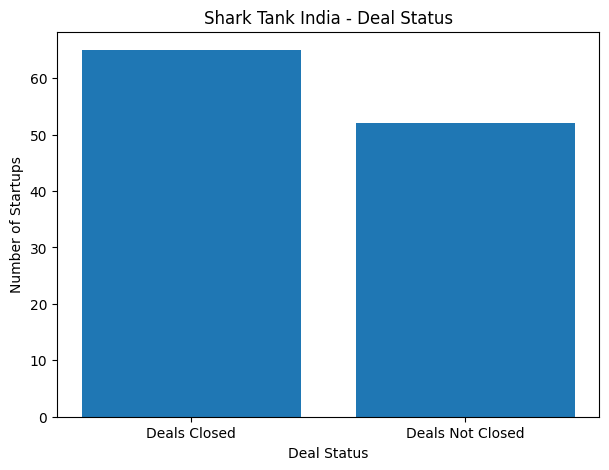

In [9]:
import matplotlib.pyplot as plt

labels = ["Deals Closed", "Deals Not Closed"]
values = [df["deal"].sum(), (df["deal"] == 0).sum()]

plt.figure(figsize=(7,5))
plt.bar(labels, values)
plt.title("Shark Tank India - Deal Status")
plt.xlabel("Deal Status")
plt.ylabel("Number of Startups")
plt.show()

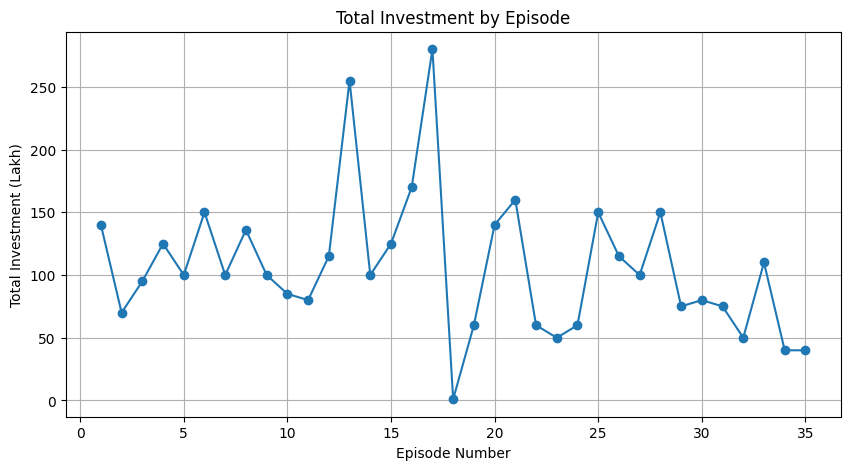

In [10]:
episode_investment = df.groupby("episode_number")["deal_amount"].sum()

plt.figure(figsize=(10,5))
plt.plot(episode_investment.index, episode_investment.values, marker="o")
plt.title("Total Investment by Episode")
plt.xlabel("Episode Number")
plt.ylabel("Total Investment (Lakh)")
plt.grid(True)
plt.show()

In [11]:
sharks = {
    "Ashneer": "ashneer_deal",
    "Anupam": "anupam_deal",
    "Aman": "aman_deal",
    "Namita": "namita_deal",
    "Vineeta": "vineeta_deal",
    "Peyush": "peyush_deal",
    "Ghazal": "ghazal_deal"
}

shark_deals = {name: df[column].sum() for name, column in sharks.items()}

print(shark_deals)

{'Ashneer': np.int64(21), 'Anupam': np.int64(24), 'Aman': np.int64(28), 'Namita': np.int64(22), 'Vineeta': np.int64(15), 'Peyush': np.int64(27), 'Ghazal': np.int64(7)}


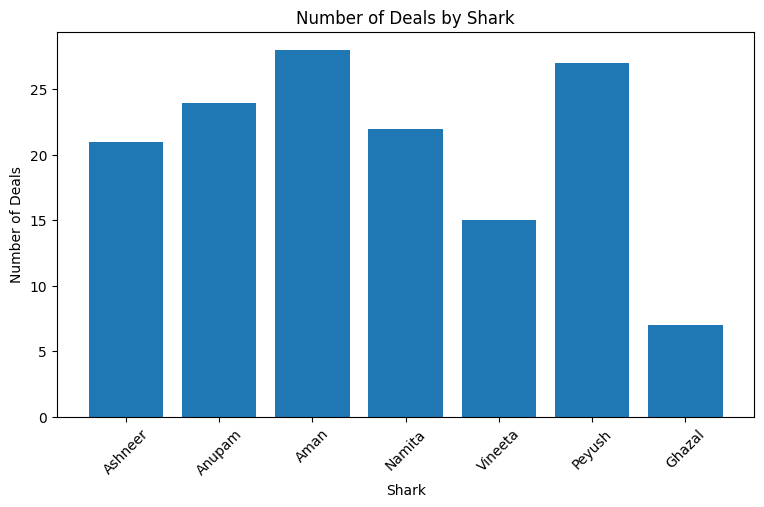

In [12]:
plt.figure(figsize=(9,5))

plt.bar(shark_deals.keys(), shark_deals.values())

plt.title("Number of Deals by Shark")
plt.xlabel("Shark")
plt.ylabel("Number of Deals")
plt.xticks(rotation=45)

plt.show()

In [13]:
shark_columns = {
    "Ashneer": "ashneer_deal",
    "Anupam": "anupam_deal",
    "Aman": "aman_deal",
    "Namita": "namita_deal",
    "Vineeta": "vineeta_deal",
    "Peyush": "peyush_deal",
    "Ghazal": "ghazal_deal"
}

shark_investment = {}

for shark, column in shark_columns.items():
    shark_investment[shark] = df.loc[df[column] == 1, "deal_amount"].sum()

print(shark_investment)

{'Ashneer': np.float64(1316.0), 'Anupam': np.float64(1346.00106), 'Aman': np.float64(1775.00005), 'Namita': np.float64(1445.00106), 'Vineeta': np.float64(930.0), 'Peyush': np.float64(1556.00101), 'Ghazal': np.float64(415.00101)}


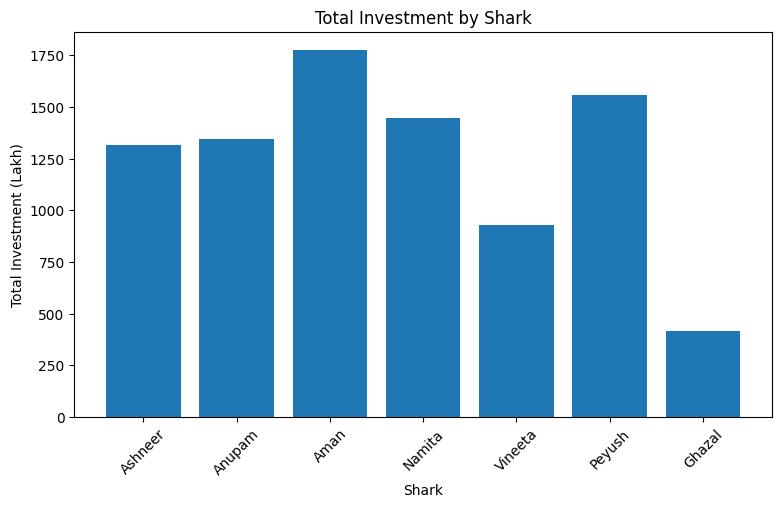

In [14]:
plt.figure(figsize=(9,5))

plt.bar(shark_investment.keys(), shark_investment.values())

plt.title("Total Investment by Shark")
plt.xlabel("Shark")
plt.ylabel("Total Investment (Lakh)")
plt.xticks(rotation=45)

plt.show()

In [15]:
total_ask = df["pitcher_ask_amount"].sum()
total_deal = df["deal_amount"].sum()

print("Total Amount Asked:", round(total_ask, 2), "Lakh")
print("Total Amount Invested:", round(total_deal, 2), "Lakh")

Total Amount Asked: 37423.0 Lakh
Total Amount Invested: 3742.0 Lakh


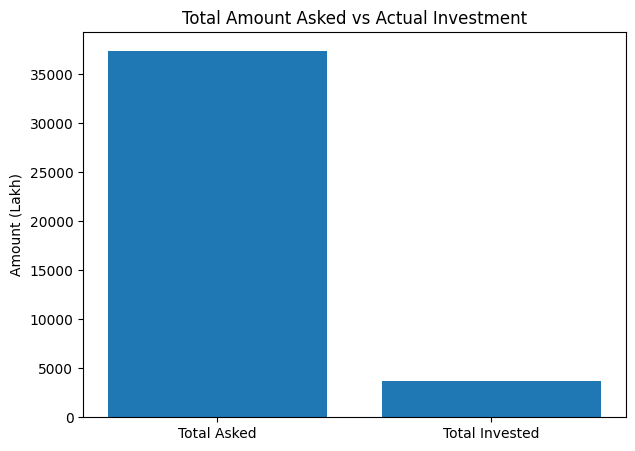

In [16]:
plt.figure(figsize=(7,5))

labels = ["Total Asked", "Total Invested"]
values = [total_ask, total_deal]

plt.bar(labels, values)

plt.title("Total Amount Asked vs Actual Investment")
plt.ylabel("Amount (Lakh)")

plt.show()

In [17]:
top_startups = df[df["deal_amount"] > 0].nlargest(10, "deal_amount")

print(top_startups[["brand_name", "deal_amount"]])

            brand_name  deal_amount
50       Aas Vidyalaya        150.0
36               Annie        105.0
12         Revamp Moto        100.0
15         Skippi Pops        100.0
18  Raising Superstars        100.0
38     The Yarn Bazaar        100.0
39   The Renal Project        100.0
42    Hammer Lifestyle        100.0
63            IN A CAN        100.0
64          Get a Whey        100.0


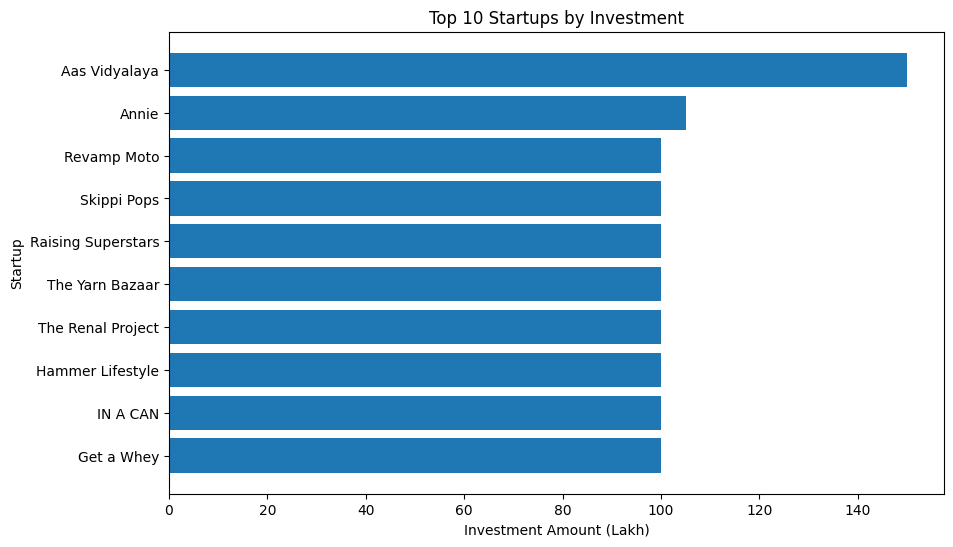

In [18]:
plt.figure(figsize=(10,6))

plt.barh(top_startups["brand_name"], top_startups["deal_amount"])

plt.title("Top 10 Startups by Investment")
plt.xlabel("Investment Amount (Lakh)")
plt.ylabel("Startup")

plt.gca().invert_yaxis()

plt.show()

In [19]:
shark_investment_actual = {}

for shark, column in shark_columns.items():
    shark_investment_actual[shark] = df.loc[df[column] == 1, "amount_per_shark"].sum()

print(shark_investment_actual)

{'Ashneer': np.float64(494.33333333), 'Anupam': np.float64(533.83360253), 'Aman': np.float64(887.500016693), 'Namita': np.float64(648.333602533), 'Vineeta': np.float64(328.3333333300001), 'Peyush': np.float64(719.6669191630001), 'Ghazal': np.float64(130.0002525)}


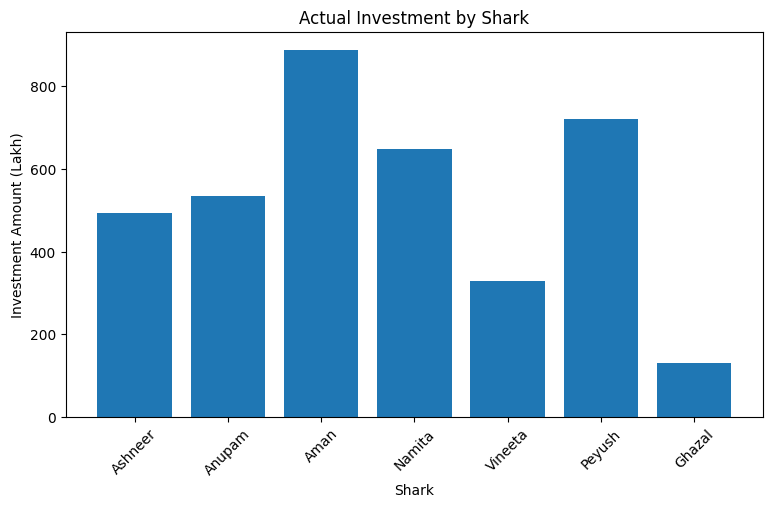

In [20]:
plt.figure(figsize=(9,5))

plt.bar(shark_investment_actual.keys(), shark_investment_actual.values())

plt.title("Actual Investment by Shark")
plt.xlabel("Shark")
plt.ylabel("Investment Amount (Lakh)")
plt.xticks(rotation=45)

plt.show()

In [21]:
print("----- FINAL PROJECT INSIGHTS -----")

print("Total Startups:", len(df))
print("Deals Closed:", int(df["deal"].sum()))
print("Deals Not Closed:", int((df["deal"] == 0).sum()))

print("Total Investment:", round(df["deal_amount"].sum(), 2), "Lakh")
print("Average Investment:", round(df["deal_amount"].mean(), 2), "Lakh")
print("Average Equity:", round(df["deal_equity"].mean(), 2), "%")

print("Highest Investment Startup:",
      df.loc[df["deal_amount"].idxmax(), "brand_name"])

print("Highest Investment:",
      df["deal_amount"].max(), "Lakh")

print("Most Active Shark:",
      max(shark_deals, key=shark_deals.get))

print("Highest Actual Investment Shark:",
      max(shark_investment_actual, key=shark_investment_actual.get))

----- FINAL PROJECT INSIGHTS -----
Total Startups: 117
Deals Closed: 65
Deals Not Closed: 52
Total Investment: 3742.0 Lakh
Average Investment: 31.98 Lakh
Average Equity: 8.96 %
Highest Investment Startup: Aas Vidyalaya
Highest Investment: 150.0 Lakh
Most Active Shark: Aman
Highest Actual Investment Shark: Aman
